# EDM Tutorial: E(3) Equivariant Diffusion for 3D Molecule Generation

This notebook demonstrates:
1. Understanding E(3) equivariance
2. Training EDM on QM9 dataset
3. Generating novel 3D molecules
4. Evaluating generated molecules
5. Path to protein/antibody generation

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add project to path
sys.path.append('../..')

from edm_3d.models.edm import EDM
from edm_3d.data.qm9_loader import prepare_qm9_data
from edm_3d.training.trainer import EDMTrainer
from edm_3d.generation.sampler import EDMSampler
from edm_3d.evaluation import metrics, visualization

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/home/jantine/miniconda3/envs/diff_gnn/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning depende

In [2]:
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    print("No CUDA GPU available")

GPU 0: NVIDIA GeForce RTX 2080 SUPER


## What is E(3) Equivariance?

E(3) = Euclidean group in 3D (rotations + translations + reflections)

Key property: Model predictions transform the same way as inputs

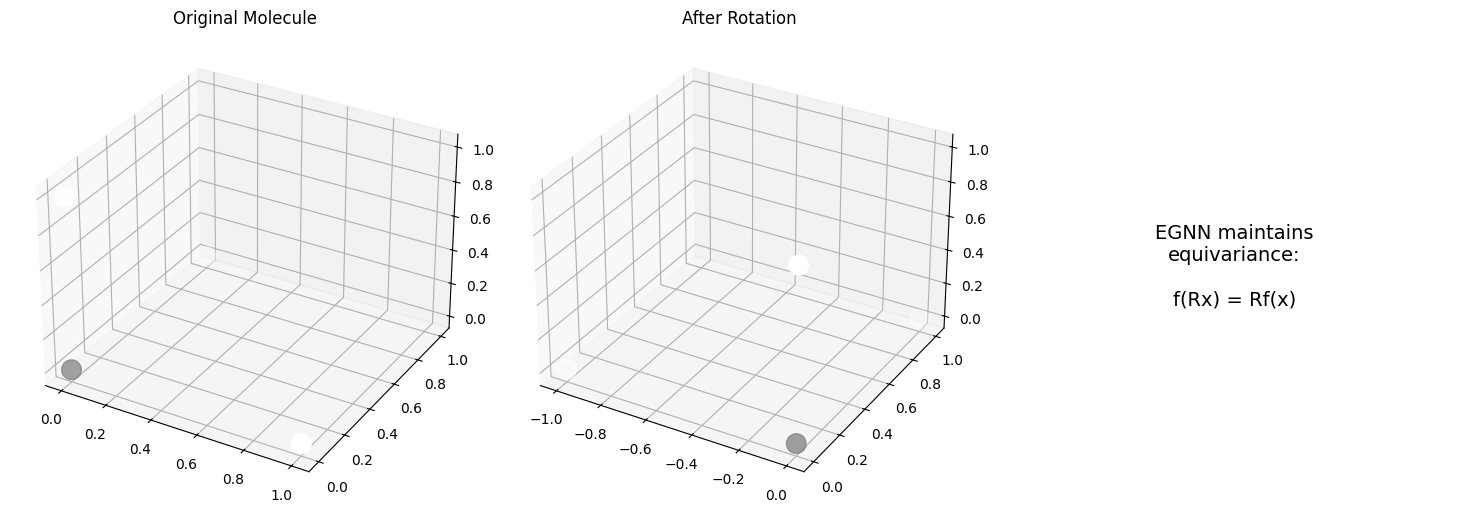

In [3]:
# Create simple molecule
def create_toy_molecule():
    coords = torch.tensor([
        [0.0, 0.0, 0.0],  # C
        [1.0, 0.0, 0.0],  # H
        [0.0, 1.0, 0.0],  # H
        [0.0, 0.0, 1.0],  # H
    ])
    return coords

# Demonstrate equivariance
coords_original = create_toy_molecule()

# Apply rotation
rotation_matrix = torch.tensor([
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
], dtype=torch.float32)

coords_rotated = coords_original @ rotation_matrix.T

# Visualize
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(*coords_original.T, s=200, c=['gray', 'white', 'white', 'white'])
ax1.set_title('Original Molecule')

ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(*coords_rotated.T, s=200, c=['gray', 'white', 'white', 'white'])
ax2.set_title('After Rotation')

ax3 = fig.add_subplot(133)
ax3.text(0.5, 0.5, 'EGNN maintains\nequivariance:\n\nf(Rx) = Rf(x)',
         ha='center', va='center', fontsize=14)
ax3.axis('off')

plt.tight_layout()
plt.show()


## QM9 Dataset

- 134k small organic molecules
- ~9 atoms on average (up to 29 atoms)
- Elements: H, C, N, O, F
- 3D coordinates + molecular properties

INFO:edm_3d.data.qm9_loader:Loading QM9 dataset from DeepChem...
INFO:deepchem.molnet.load_function.molnet_loader:About to featurize qm9 dataset.
INFO:deepchem.data.data_loader:Loading raw samples now.
INFO:deepchem.data.data_loader:shard_size: 4096
INFO:deepchem.utils.data_utils:Reading structures from /tmp/gdb9.sdf.
[06:38:58] Explicit valence for atom # 1 C, 5, is greater than permitted
[06:38:58] ERROR: Could not sanitize molecule ending on line 2704
[06:38:58] ERROR: Explicit valence for atom # 1 C, 5, is greater than permitted
[06:38:58] Explicit valence for atom # 1 C, 5, is greater than permitted
[06:38:58] ERROR: Could not sanitize molecule ending on line 9097
[06:38:58] ERROR: Explicit valence for atom # 1 C, 5, is greater than permitted
[06:38:58] Explicit valence for atom # 2 C, 5, is greater than permitted
[06:38:58] ERROR: Could not sanitize molecule ending on line 19803
[06:38:58] ERROR: Explicit valence for atom # 2 C, 5, is greater than permitted
[06:38:58] Explicit va

Training samples: 10000
Validation samples: 2000
Test samples: 2000
Analyzing 1000 molecules for statistics...
  Processed 0/1000...


  Processed 100/1000...


  Processed 200/1000...


  Processed 300/1000...


...

  Processed 500/1000...


  Processed 600/1000...


  Processed 700/1000...


  Processed 800/1000...


  Processed 900/1000...


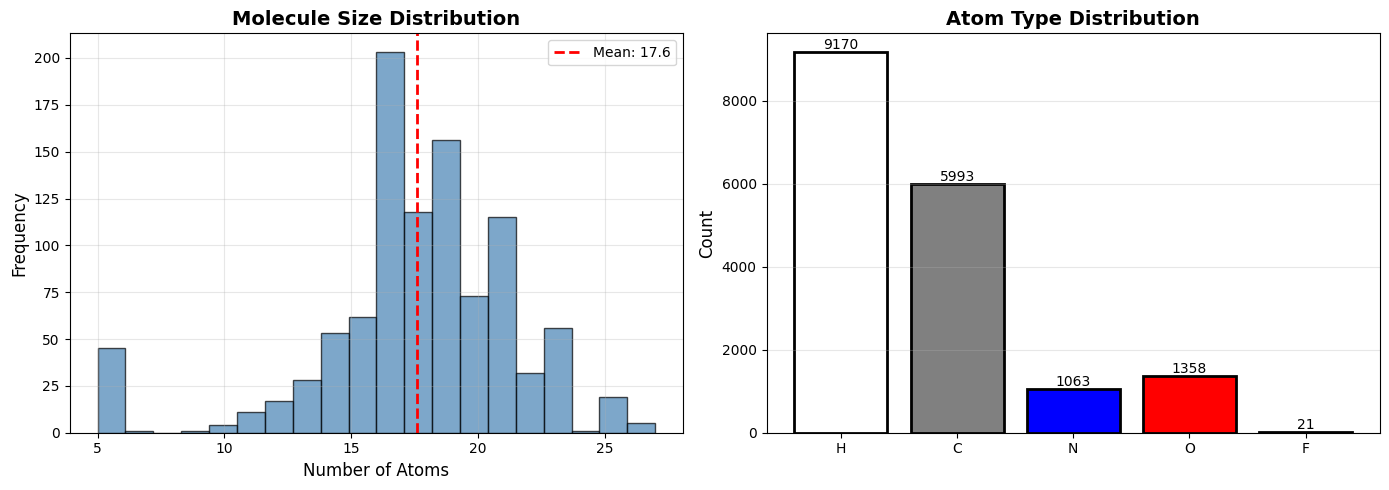


✓ Statistics computed from 1000 molecules



Example molecule: C
Number of atoms: 5


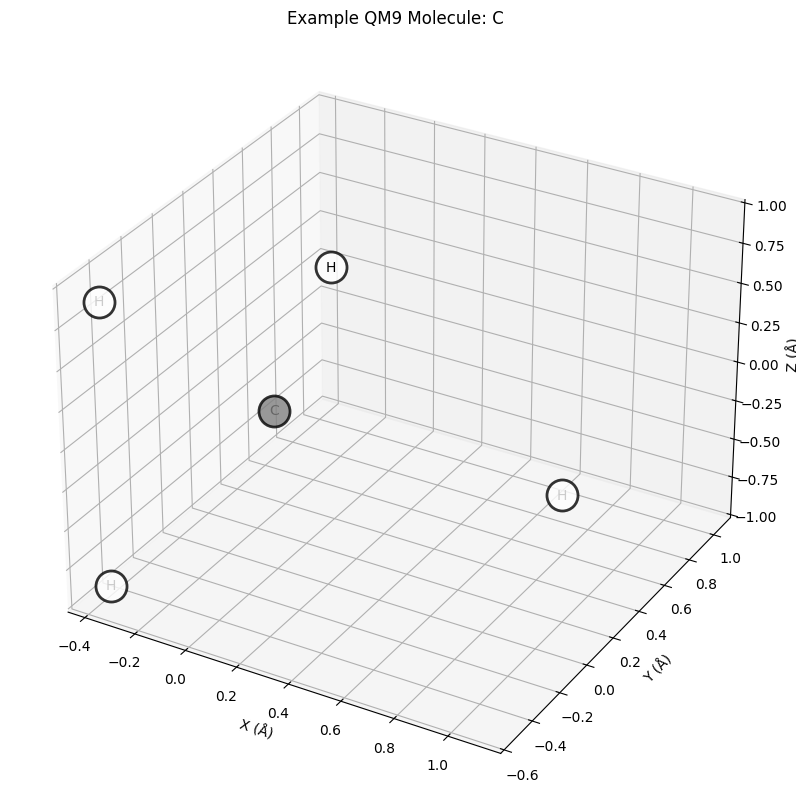


Visualizing 4 example molecules...


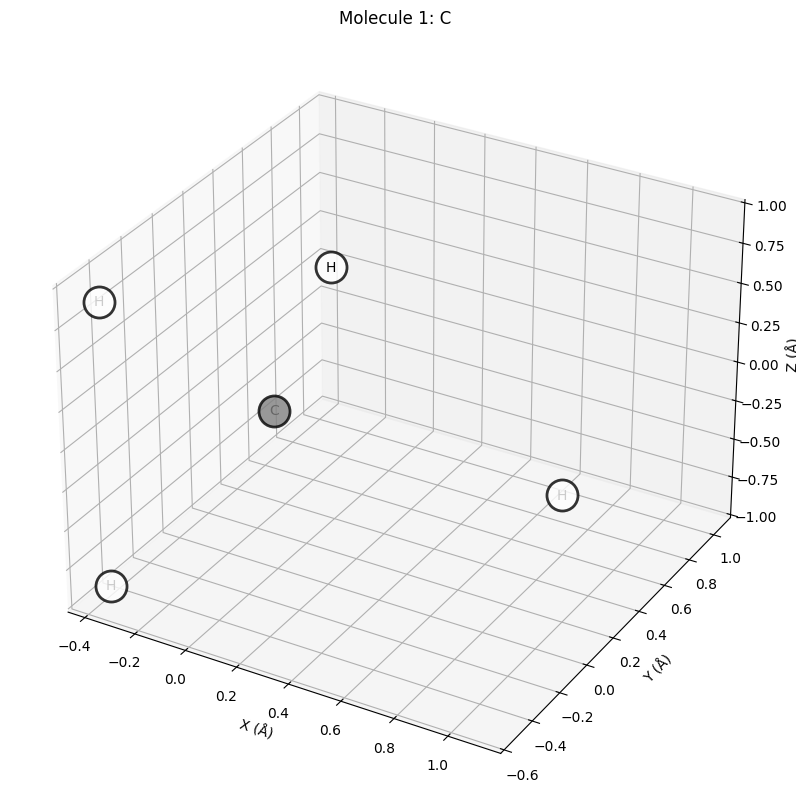

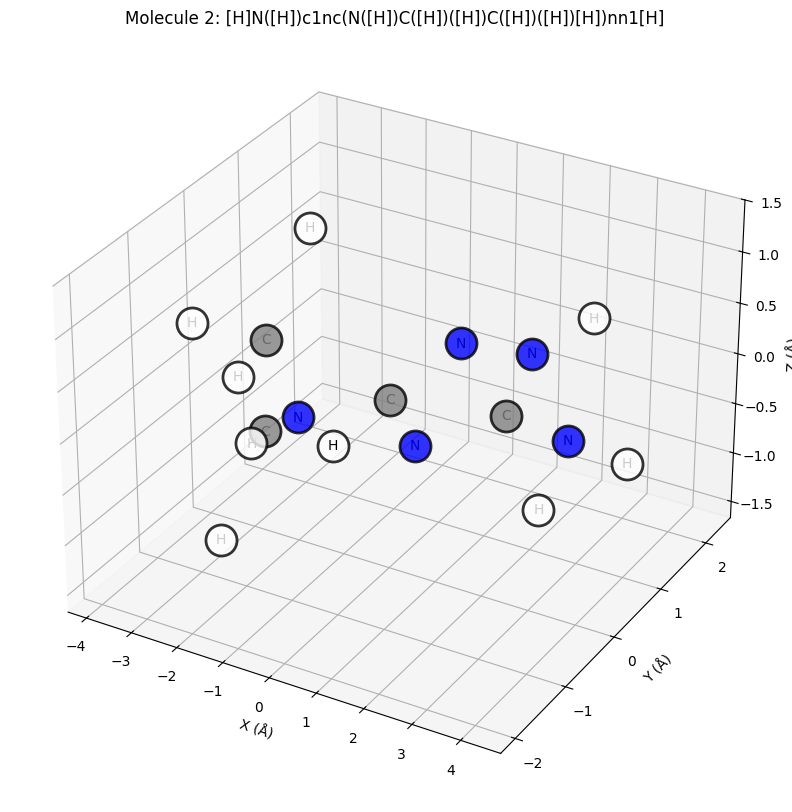

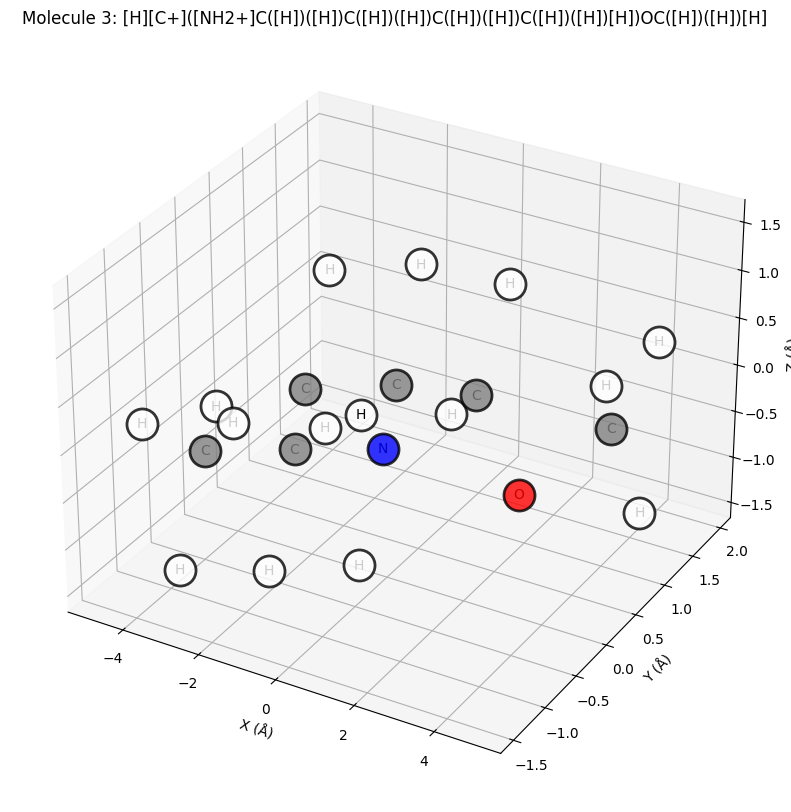

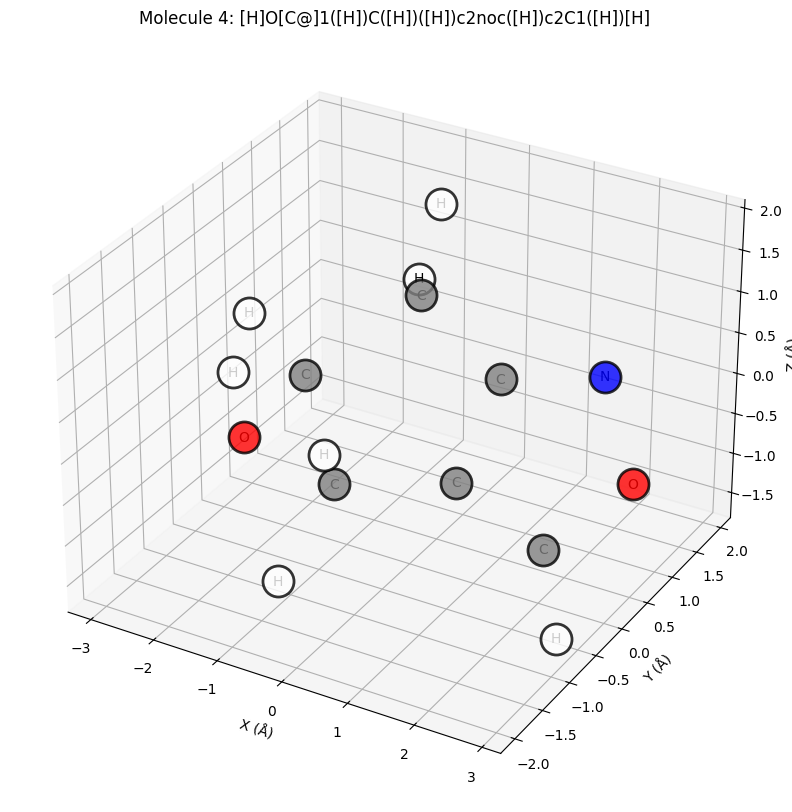

In [4]:
from edm_3d.data.qm9_loader import prepare_qm9_data
from edm_3d.evaluation import visualization

# Load subset of data
train_data, val_data, test_data = prepare_qm9_data(max_samples=10000)

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")

# Analyze dataset statistics
visualization.plot_dataset_statistics(train_data)

# Show example molecule - coords and atom_types are already single molecule
sample_mol = train_data[0]
print(f"\nExample molecule: {sample_mol['smiles']}")
print(f"Number of atoms: {sample_mol['num_atoms']}")

# Call visualize_molecule - it will handle single molecule correctly
visualization.visualize_molecule(
    coords=sample_mol['coords'],        # Shape: [N, 3]
    atom_types=sample_mol['atom_types'], # Shape: [N]
    title=f"Example QM9 Molecule: {sample_mol['smiles']}"
)

# Show multiple examples
print("\nVisualizing 4 example molecules...")
for i in range(4):
    mol = train_data[i]
    visualization.visualize_molecule(
        coords=mol['coords'],
        atom_types=mol['atom_types'],
        title=f"Molecule {i+1}: {mol['smiles']}"
    )

## EDM Architecture

Components:
1. EGNN: E(3)-equivariant message passing
2. Diffusion Process: Noise schedule
3. Time Embedding: Condition on timestep

In [5]:
# ============================================================================
# Cell 4: Initialize EDM Model
# ============================================================================

from edm_3d.models.edm import EDM

model = EDM(
    num_atom_types=5,
    hidden_dim=128,  # Reduced from 256
    num_layers=4,     # Reduced from 9
    num_diffusion_steps=100,  # Reduced from 1000 for demo
    learning_rate=1e-4
)

# Print model architecture
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

INFO:edm_3d.models.edm:Initialized EDMCore with 496,901 parameters
INFO:edm_3d.models.edm:Initialized EDM on device: cuda


EDM(
  num_atom_types=5,
  hidden_dim=128,
  num_layers=4,
  num_diffusion_steps=100,
  total_params=496,901,
  trainable_params=496,901,
  device=cuda
)

Total parameters: 496,901


## Forward Diffusion Process

Gradually add noise to molecules over T=1000 steps

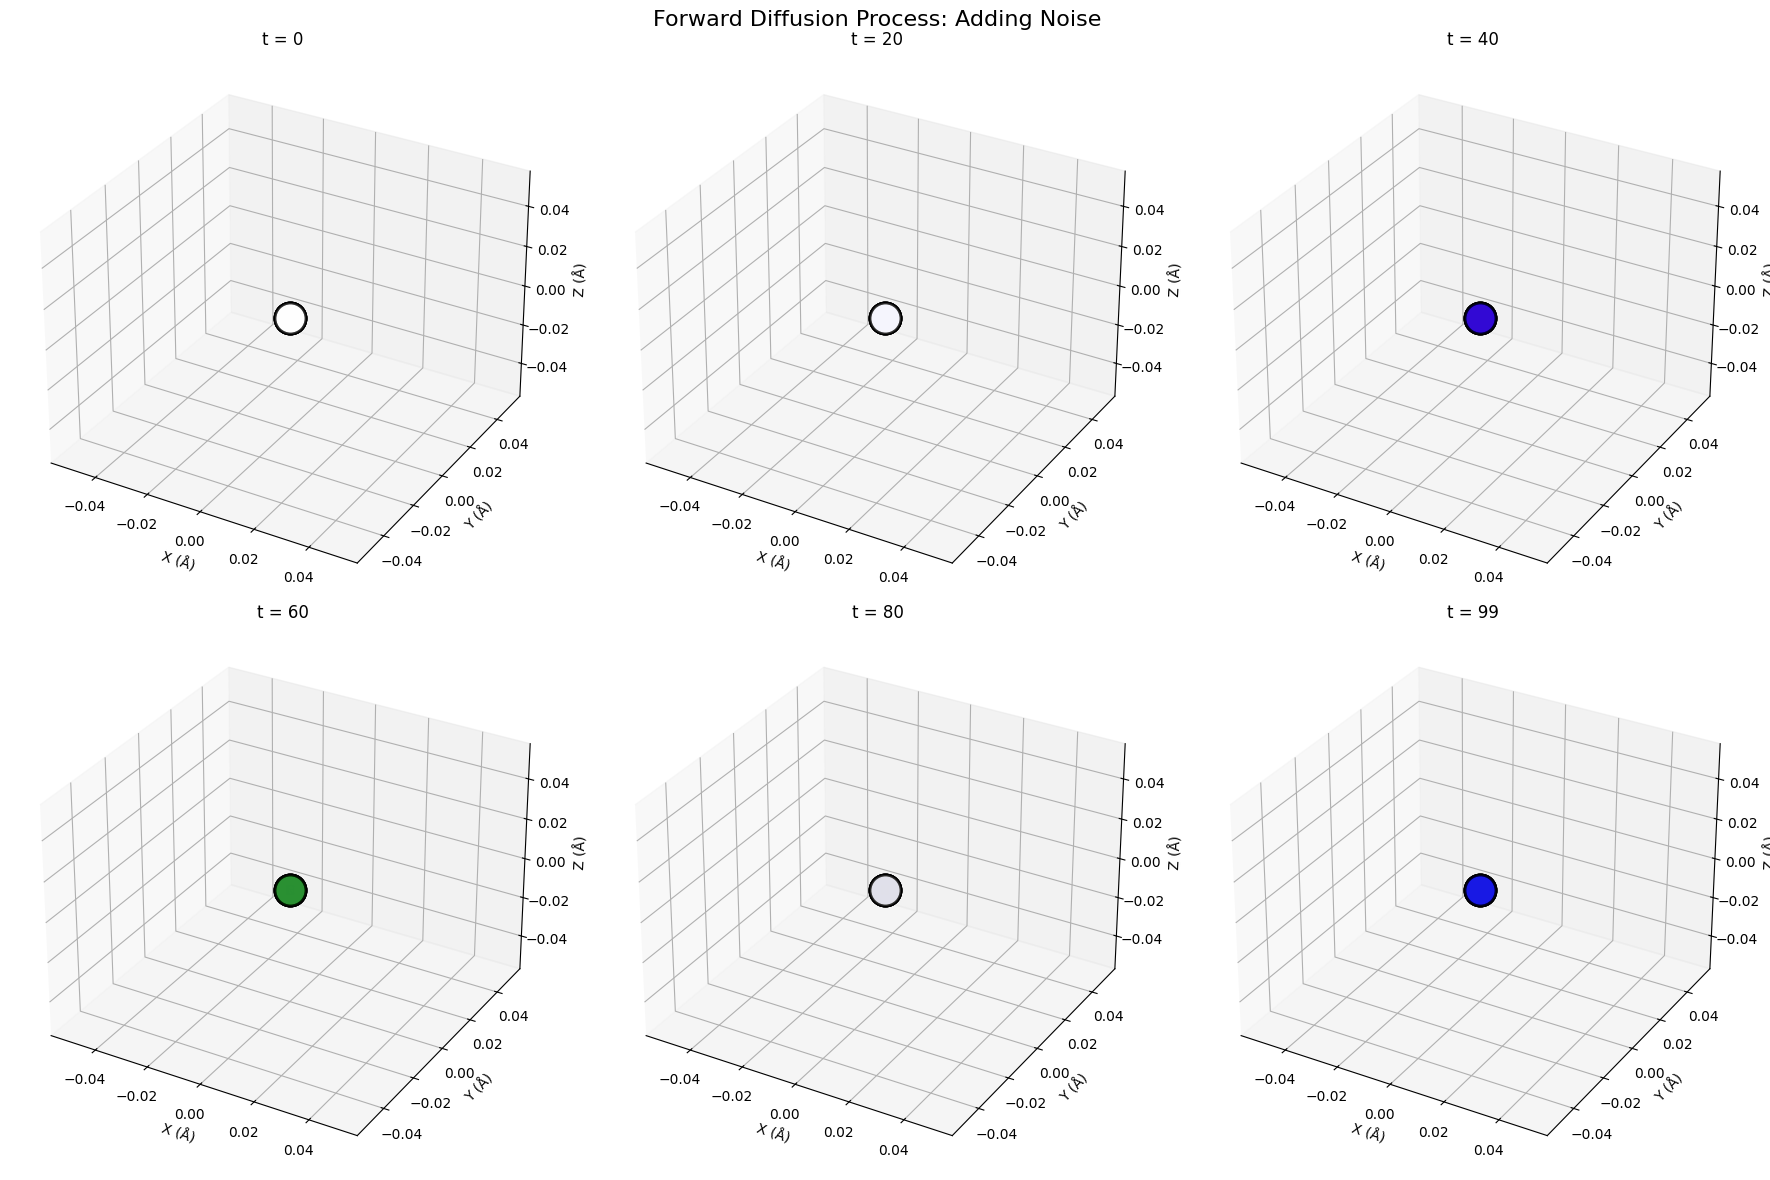

In [6]:
# ============================================================================
# Cell 5: Visualize Forward Diffusion Process
# ============================================================================

import torch
from edm_3d.evaluation import visualization

# Take a sample molecule
sample_coords = train_data[0]['coords']
sample_atoms = train_data[0]['atom_types']

# Show diffusion at different timesteps
timesteps = [0, 20, 40, 60, 80, 99]  # Adjusted for num_diffusion_steps=100

fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={'projection': '3d'})
axes = axes.flatten()

# Convert atom types to one-hot
atom_types_onehot = torch.zeros(len(sample_atoms), 5)
atom_types_onehot.scatter_(1, sample_atoms.unsqueeze(1), 1.0)

for idx, t in enumerate(timesteps):
    # Forward diffusion
    noisy_coords, noisy_atoms, _, _ = model.model.diffusion.forward_diffusion(
        sample_coords.unsqueeze(0),
        atom_types_onehot.unsqueeze(0),
        torch.tensor([t])
    )

    # Convert back to discrete atom types for visualization
    noisy_atoms_discrete = torch.argmax(noisy_atoms[0], dim=-1)

    # Plot
    ax = axes[idx]
    visualization.plot_3d_molecule(
        noisy_coords[0],
        noisy_atoms_discrete,
        ax=ax,
        title=f't = {t}'
    )

plt.suptitle('Forward Diffusion Process: Adding Noise', fontsize=16)
plt.tight_layout()
plt.show()

## Training EDM

Training time: ~7 days on single GPU (as per paper)
For this tutorial, we'll train for a few epochs or load pretrained weights

INFO:edm_3d.training.trainer:Initialized EDMTrainer with 10000 train samples
INFO:edm_3d.training.trainer:Starting training for 10 epochs


Starting training...

Epoch 1/10


Validating: 100%|██████████| 63/63 [01:04<00:00,  1.03s/it, loss=0.4040]


Train Loss: 3913.9922 | Val Loss: 0.5174

Epoch 2/10


Validating: 100%|██████████| 63/63 [00:41<00:00,  1.53it/s, loss=0.4466]


...

Train Loss: 0.3166 | Val Loss: 0.3267

Epoch 9/10


Validating: 100%|██████████| 63/63 [00:41<00:00,  1.52it/s, loss=0.4074]


Train Loss: 0.3022 | Val Loss: 0.2935

Epoch 10/10


Validating: 100%|██████████| 63/63 [00:41<00:00,  1.53it/s, loss=0.3775]
INFO:edm_3d.models.edm:Model saved to ../experiments/results/edm_3d_small/edm_final.pth
INFO:edm_3d.training.trainer:Training complete!


Train Loss: 0.3057 | Val Loss: 0.3100
  → Checkpoint saved: checkpoint_epoch_10.pth


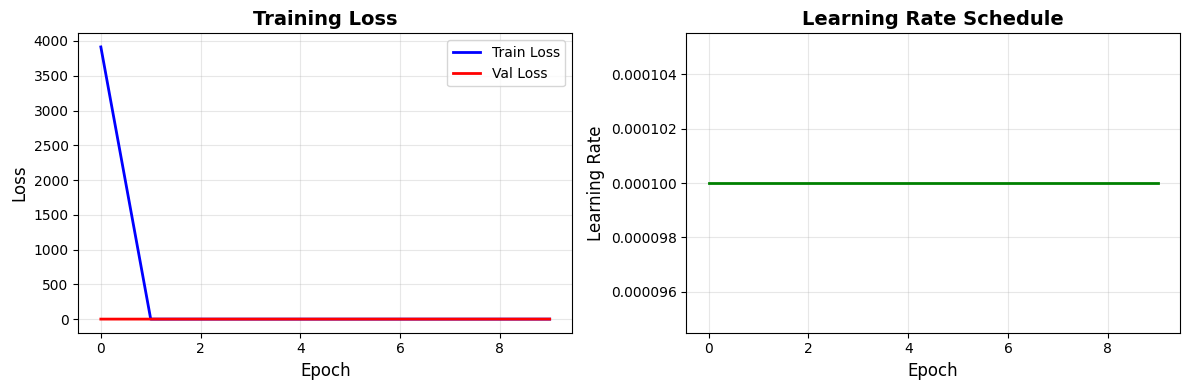


✓ Training complete!
Final train loss: 0.3057
Final val loss: 0.3100


In [7]:
# ============================================================================
# Cell 6: Train EDM
# ============================================================================

from edm_3d.training.trainer import EDMTrainer
import matplotlib.pyplot as plt

# Train from scratch (reduced epochs for demo)
trainer = EDMTrainer(
    model=model,
    train_data=train_data,
    val_data=val_data,
    num_epochs=10,  # Just 10 epochs for tutorial
    batch_size=32,
    save_dir='../experiments/results/edm_3d_small/'
)

print("Starting training...")
history = trainer.train()

# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], 'b-', label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], 'r-', label='Val Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.title('Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['learning_rate'], 'g-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.title('Learning Rate Schedule', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Training complete!")
print(f"Final train loss: {history['train_loss'][-1]:.4f}")
print(f"Final val loss: {history['val_loss'][-1]:.4f}")

# Model is automatically saved to ../experiments/results/edm_3d_small/edm_final.pth

## Molecule Generation

Sample from learned distribution using reverse diffusion

In [8]:
# ============================================================================
# Cell 7: Generate Molecules (GPU OPTIMIZED)
# ============================================================================

from edm_3d.generation.sampler import EDMSampler
import torch

sampler = EDMSampler(model)

# Generate molecules - will automatically use GPU if model is on GPU
num_molecules = 16
print(f"Generating {num_molecules} molecules on {model.device}...")

generated_coords, generated_atoms = sampler.sample(
    num_molecules=num_molecules,
    num_atoms=9,  # Average QM9 size
    device=model.device  # Use model's device (GPU)
)

print(f"✓ Generated {num_molecules} molecules")
print(f"Coordinates shape: {generated_coords.shape}")
print(f"Atom types shape: {generated_atoms.shape}")
print(f"Generated on device: {model.device}")

# Coordinates and atom_types are now on CPU for visualization

INFO:edm_3d.generation.sampler:Initialized EDMSampler on device: cuda
INFO:edm_3d.generation.sampler:Generating 16 molecules with 9 atoms on cuda


Generating 16 molecules on cuda...


INFO:edm_3d.generation.sampler:✓ Generation complete


✓ Generated 16 molecules
Coordinates shape: torch.Size([16, 9, 3])
Atom types shape: torch.Size([16, 9])
Generated on device: cuda


## Visualize Generated Molecules

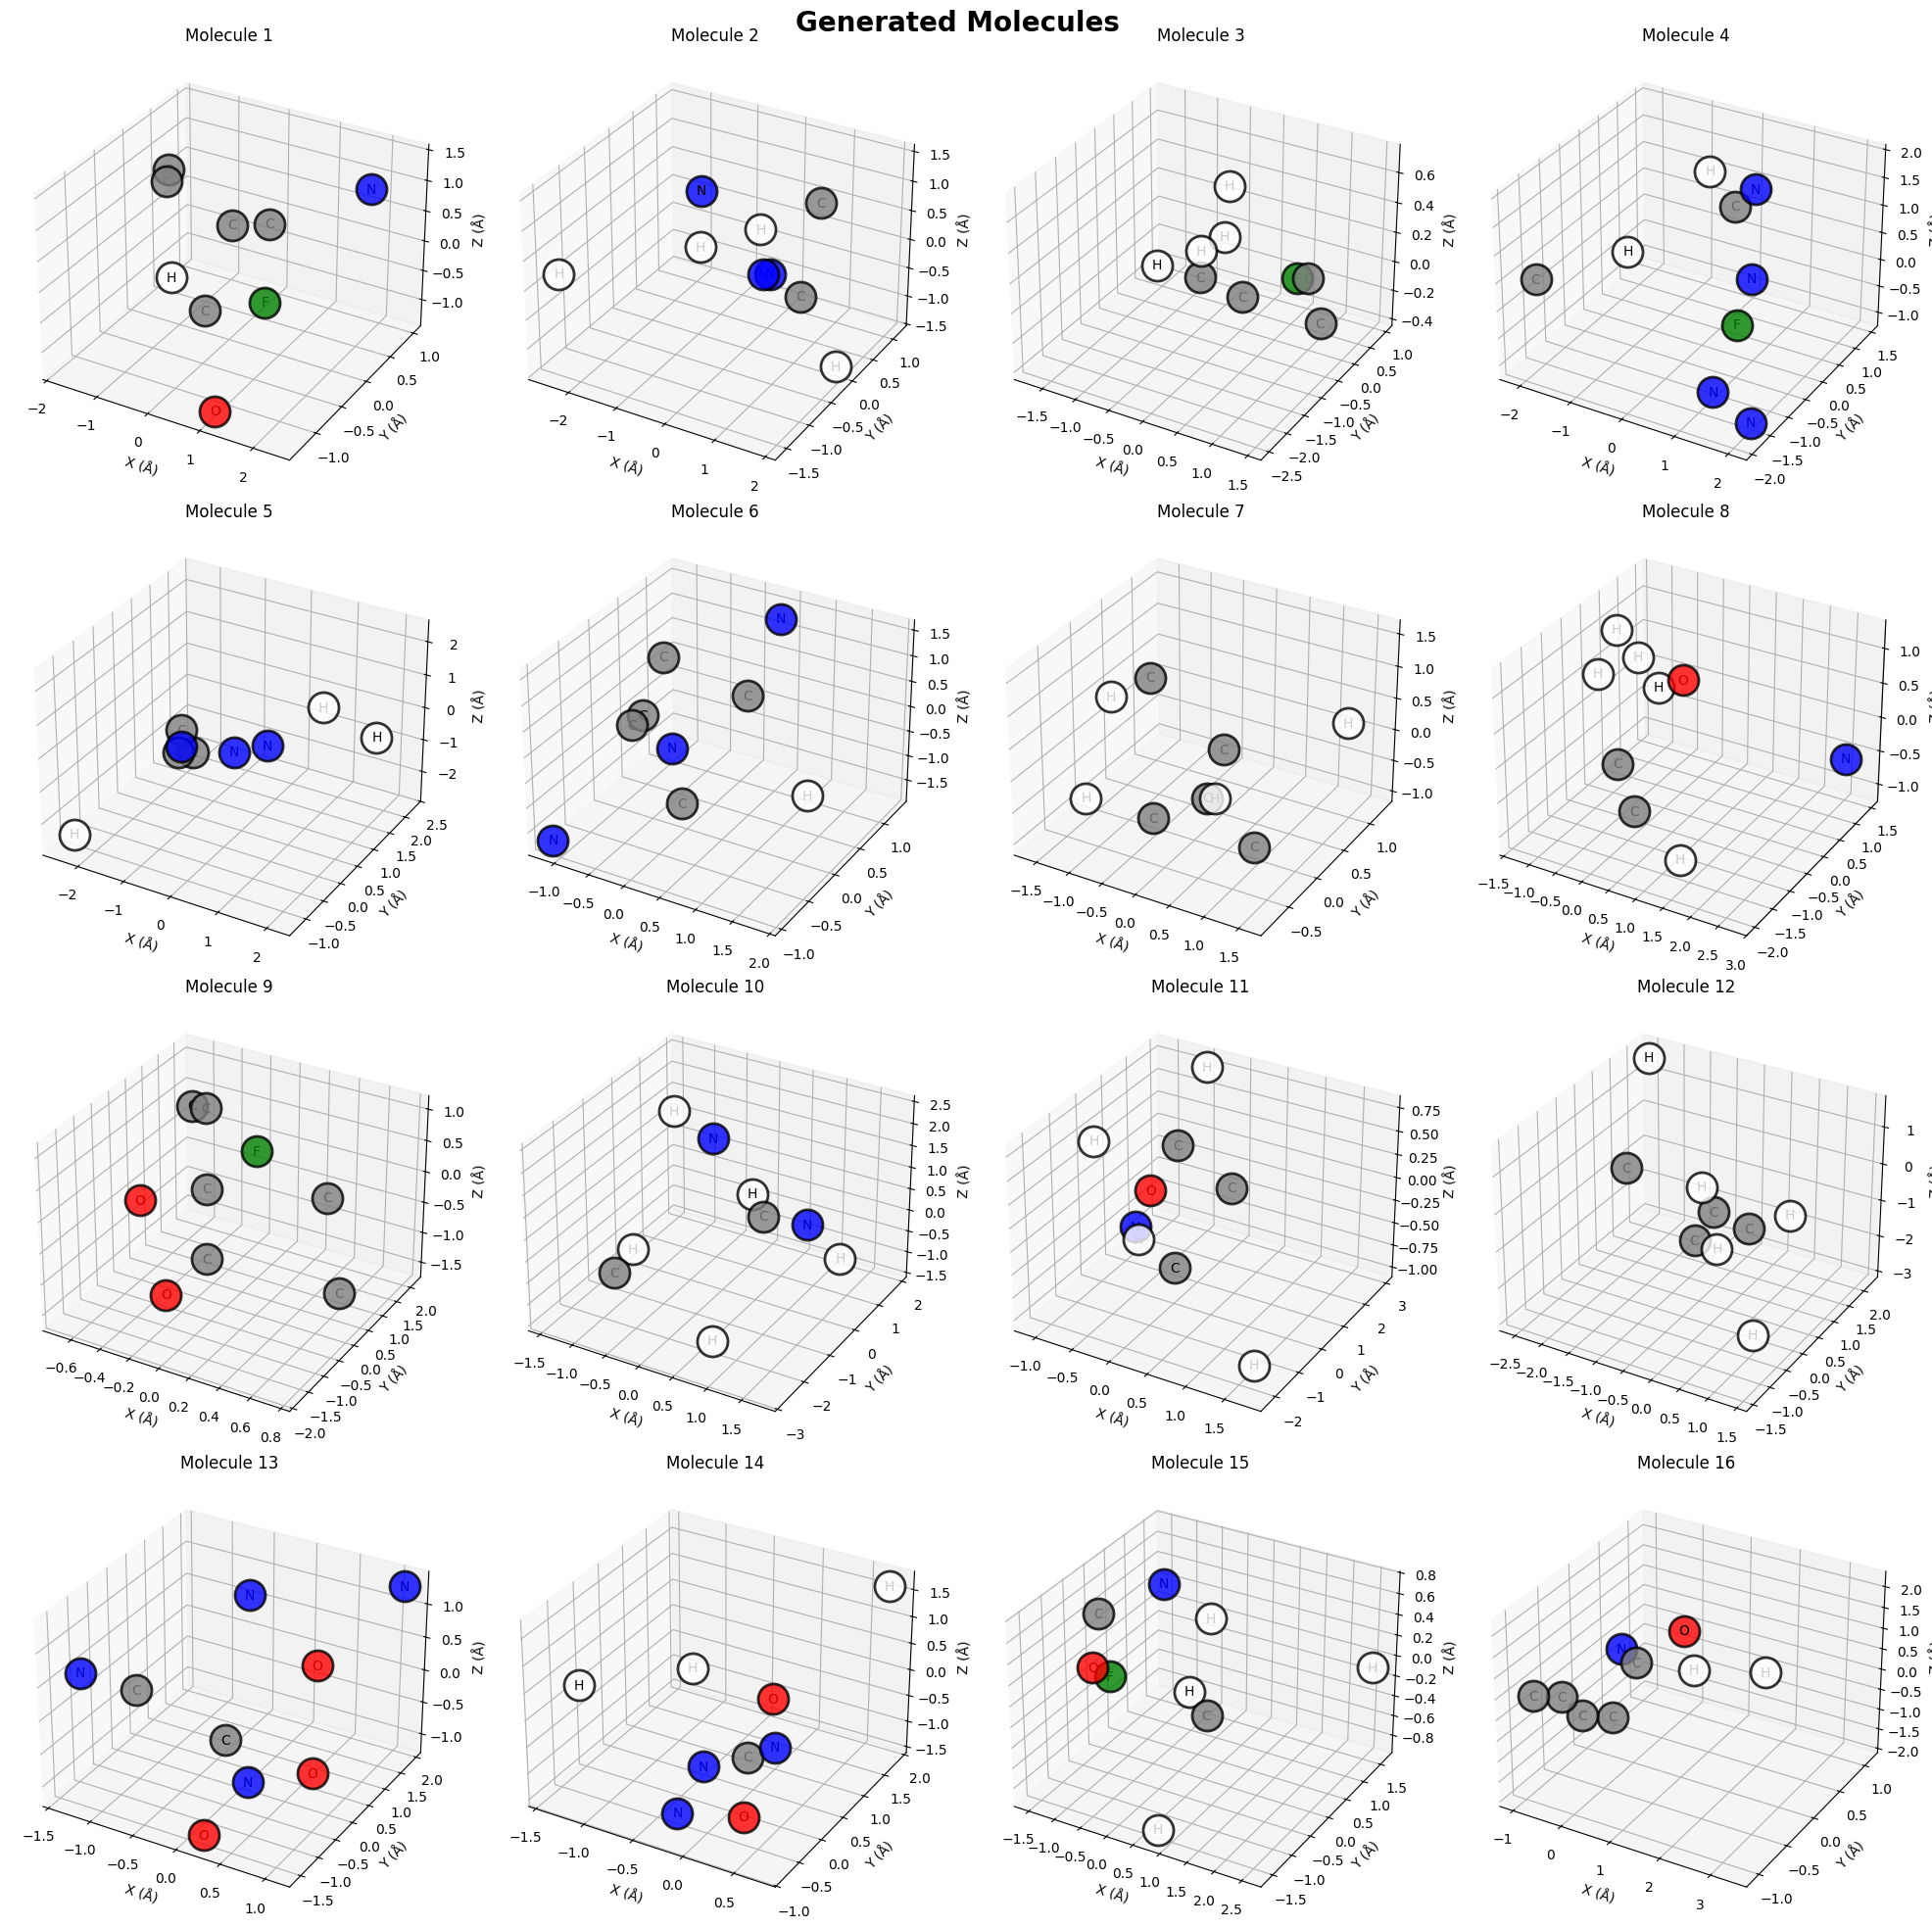


✓ Visualization complete!

Generated molecule statistics:
  Average atoms per molecule: 9
  Coordinate range: [-2.85, 3.38]

Atom type distribution:
  H: 47 (32.6%)
  C: 53 (36.8%)
  N: 27 (18.8%)
  O: 12 (8.3%)
  F: 5 (3.5%)


In [9]:
# ============================================================================
# Cell 8: Visualize Generated Molecules
# ============================================================================

from edm_3d.evaluation import visualization
import matplotlib.pyplot as plt

# Show grid of generated molecules
fig, axes = plt.subplots(4, 4, figsize=(20, 20), subplot_kw={'projection': '3d'})
axes = axes.flatten()

for idx in range(16):
    visualization.plot_3d_molecule(
        generated_coords[idx],
        generated_atoms[idx],
        ax=axes[idx],
        title=f'Molecule {idx+1}'
    )

plt.suptitle('Generated Molecules', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")

# Show some statistics
print("\nGenerated molecule statistics:")
print(f"  Average atoms per molecule: {generated_coords.shape[1]}")
print(f"  Coordinate range: [{generated_coords.min():.2f}, {generated_coords.max():.2f}]")

# Count atom types
atom_counts = {}
for mol_atoms in generated_atoms:
    for atom in mol_atoms:
        atom_type = int(atom.item())
        atom_counts[atom_type] = atom_counts.get(atom_type, 0) + 1

atom_names = {0: 'H', 1: 'C', 2: 'N', 3: 'O', 4: 'F'}
print("\nAtom type distribution:")
for atom_type, count in sorted(atom_counts.items()):
    print(f"  {atom_names[atom_type]}: {count} ({count/(16*9)*100:.1f}%)")

## Reverse Diffusion: From Noise to Molecule

Watch a molecule being generated step-by-step

INFO:edm_3d.generation.sampler:Generating 1 molecules with 9 atoms on cuda
INFO:edm_3d.generation.sampler:✓ Generation complete


Animation with 10 frames


TypeError: only length-1 arrays can be converted to Python scalars

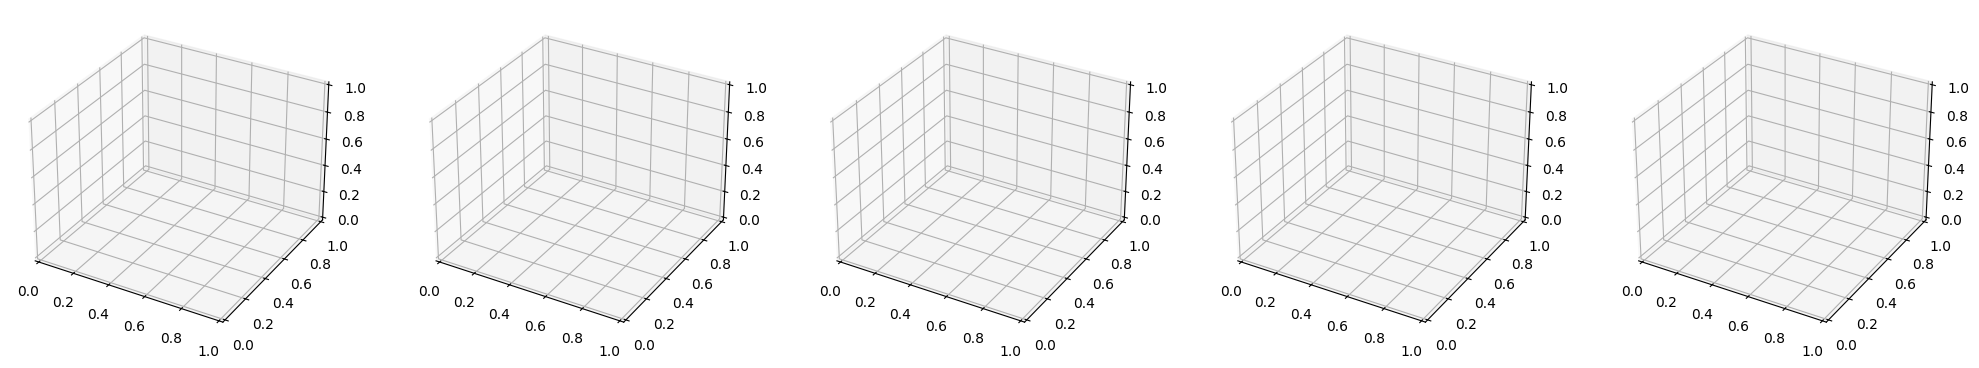

In [10]:
# Generate with intermediate steps
coords, atoms, trajectory = sampler.sample_with_trajectory(
    num_molecules=1,
    num_atoms=9,
    save_every=10,
    device=model.device
)

# Unpack trajectory into separate lists
coords_trajectory = [item[0] for item in trajectory]
atoms_trajectory = [item[1] for item in trajectory]

# Animate denoising
visualization.animate_diffusion(
    coords_trajectory,
    atoms_trajectory,
    save_path='../experiments/results/edm_3d/generation_animation.gif'
)

# Show key frames
timesteps_to_show = [0, 20, 40, 60, 80, 99]
fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={'projection': '3d'})
axes = axes.flatten()

for idx, t in enumerate(timesteps_to_show):
    step_idx = t // 10
    if step_idx < len(coords_trajectory):
        visualization.plot_3d_molecule(
            coords_trajectory[step_idx][0],
            atoms_trajectory[step_idx][0],
            ax=axes[idx],
            title=f'Step {t}'
        )

plt.suptitle('Reverse Diffusion: Molecule Generation', fontsize=16)
plt.tight_layout()
plt.show()

## Evaluation Metrics

1. **Validity**: Are molecules chemically valid?
2. **Uniqueness**: How diverse are generated molecules?
3. **Novelty**: Are molecules new (not in training set)?
4. **Stability**: Are molecular geometries stable?

[06:25:30] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[06:25:31] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[06:25:31] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[06:25:32] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[06:25:32] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[06:25:33] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[06:25:33] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[06:25:34] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[06:25:34] WARNING: could not find number of expected rings. Switching to an approximate ring fi


EVALUATION RESULTS
Validity (%)        : 100.00%
Uniqueness (%)      :  93.75%
Novelty (%)         : 100.00%
Stability (%)       : 100.00%


[06:29:14] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.


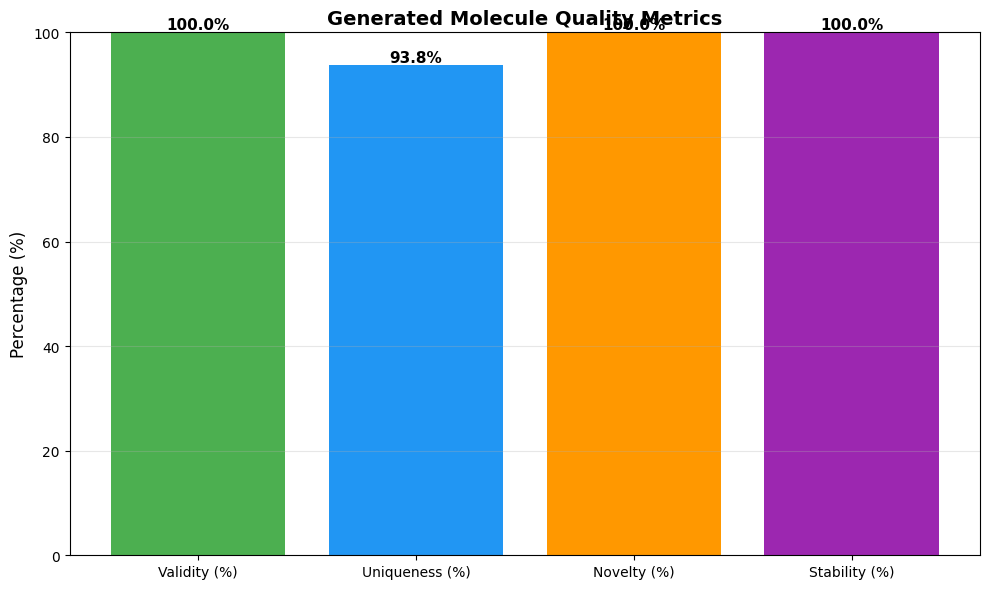

In [13]:
# Compute metrics
validity = metrics.compute_validity(generated_coords, generated_atoms)
uniqueness = metrics.compute_uniqueness(generated_coords, generated_atoms)
novelty = metrics.compute_novelty(generated_coords, generated_atoms, train_data)
stability = metrics.compute_stability(generated_coords, generated_atoms)

# Display results
results = {
    'Validity (%)': validity * 100,
    'Uniqueness (%)': uniqueness * 100,
    'Novelty (%)': novelty * 100,
    'Stability (%)': stability * 100
}

print("\n" + "="*50)
print("EVALUATION RESULTS")
print("="*50)
for metric, value in results.items():
    print(f"{metric:20s}: {value:6.2f}%")
print("="*50)

# Visualize metrics
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(results.keys(), results.values(), color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0'])
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Generated Molecule Quality Metrics', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


## Distribution Comparison

Compare properties of generated vs. training molecules

In [16]:
# Extract properties from training data
train_properties = metrics.extract_molecular_properties(train_data)
gen_properties = metrics.extract_molecular_properties_from_tensors(
    generated_coords,
    generated_atoms
)

# Plot distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

properties = [
    'num_atoms', 'num_bonds', 'avg_bond_length',
    'molecular_weight', 'radius_of_gyration',
]

for idx, prop in enumerate(properties[:6]):
    ax = axes.flatten()[idx]

    ax.hist(train_properties[prop], bins=30, alpha=0.5, label='Training', density=True)
    ax.hist(gen_properties[prop], bins=30, alpha=0.5, label='Generated', density=True)
    ax.set_xlabel(prop.replace('_', ' ').title())
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Property Distributions: Training vs Generated', fontsize=16)
plt.tight_layout()
plt.show()

AttributeError: module 'edm_3d.evaluation.metrics' has no attribute 'extract_molecular_properties'

## Understanding Model Components

Analyze what the model learned

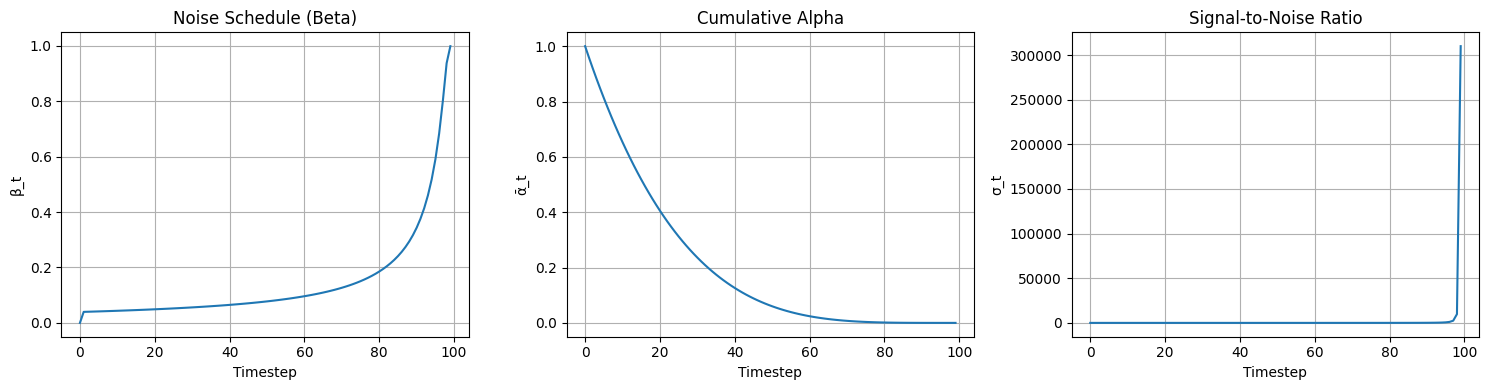

In [17]:
# 1. Noise schedule visualization
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(model.model.diffusion.betas.cpu().numpy())
plt.xlabel('Timestep')
plt.ylabel('β_t')
plt.title('Noise Schedule (Beta)')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(model.model.diffusion.alpha_bars.cpu().numpy())
plt.xlabel('Timestep')
plt.ylabel('ᾱ_t')
plt.title('Cumulative Alpha')
plt.grid(True)

plt.subplot(1, 3, 3)
sigma_t = torch.sqrt((1 - model.model.diffusion.alpha_bars) / model.model.diffusion.alpha_bars)
plt.plot(sigma_t.cpu().numpy())
plt.xlabel('Timestep')
plt.ylabel('σ_t')
plt.title('Signal-to-Noise Ratio')
plt.grid(True)

plt.tight_layout()
plt.show()

# # 2. Attention/message passing visualization
# # (If you implement attention weights tracking)
# from edm_3d.evaluation.visualization import visualize_attention_weights
#
# sample_mol_idx = 0
# attention_weights = model.get_attention_weights(
#     generated_coords[sample_mol_idx],
#     generated_atoms[sample_mol_idx]
# )
#
# visualize_attention_weights(
#     generated_coords[sample_mol_idx],
#     generated_atoms[sample_mol_idx],
#     attention_weights
# )

## Extending to Proteins/Antibodies

Current: QM9 molecules (~9 atoms, up to 29)
Target: Antibodies (~1500 atoms, 150 residues)

Challenges:
1. Scale: 50-100x more atoms
2. Complexity: 20 amino acid types vs 5 atom types
3. Structure: Secondary/tertiary structure
4. Binding: Antigen-antibody interaction

In [ ]:
# # Visualize scale difference
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
#
# # Small molecule (QM9)
# ax1.bar(['Atoms', 'Types'], [9, 5], color='steelblue')
# ax1.set_ylabel('Count')
# ax1.set_title('Small Molecule (QM9)\nEDM Current', fontsize=14, fontweight='bold')
# ax1.set_ylim(0, 1600)
#
# # Antibody
# ax2.bar(['Atoms', 'Amino Acid Types'], [1500, 20], color='coral')
# ax2.set_ylabel('Count')
# ax2.set_title('Antibody\nEDM Target', fontsize=14, fontweight='bold')
# ax2.set_ylim(0, 1600)
#
# plt.tight_layout()
# plt.show()
#
# print("""
# ROADMAP TO PROTEIN/ANTIBODY GENERATION:
#
# Phase 1: ✓ EDM on QM9 (small molecules)
# Phase 2: → Scale to larger molecules (50-100 atoms)
# Phase 3: → Peptides (20-50 residues)
# Phase 4: → Small proteins (100-200 residues)
# Phase 5: → Antibody CDR loops (10-20 residues)
# Phase 6: → Full antibody generation
#
# Key Modifications Needed:
# 1. Hierarchical architecture (residue-level + atom-level)
# 2. Conditional generation (given antigen/target)
# 3. Physics-informed constraints (Ramachandran angles)
# 4. Efficient attention mechanisms (for 1000+ atoms)
# """)

## Lightweight vs Full EDM

Compare computational requirements

In [ ]:
# import time
#
# def benchmark_model(model, num_atoms, num_samples=10):
#     """Measure inference time and memory"""
#     device = 'cuda' if torch.cuda.is_available() else 'cpu'
#     model = model.to(device)
#
#     times = []
#     for _ in range(num_samples):
#         start = time.time()
#         with torch.no_grad():
#             coords, atoms = model.generate(num_atoms=num_atoms, num_molecules=1, device=device)
#         times.append(time.time() - start)
#
#     return np.mean(times), np.std(times)
#
# # Benchmark different sizes
# sizes = [9, 29, 50, 100]
# times = []
#
# for size in sizes:
#     mean_time, std_time = benchmark_model(model, size)
#     times.append(mean_time)
#     print(f"Atoms: {size:3d} | Time: {mean_time:.2f}s ± {std_time:.2f}s")
#
# # Plot scaling
# plt.figure(figsize=(10, 6))
# plt.plot(sizes, times, 'o-', linewidth=2, markersize=10)
# plt.xlabel('Number of Atoms', fontsize=12)
# plt.ylabel('Generation Time (seconds)', fontsize=12)
# plt.title('EDM Computational Scaling', fontsize=14, fontweight='bold')
# plt.grid(True, alpha=0.3)
#
# # Extrapolate to antibody size
# from scipy.interpolate import interp1d
# f = interp1d(sizes, times, kind='quadratic', fill_value='extrapolate')
# antibody_time = f(1500)
# plt.axvline(1500, color='red', linestyle='--', label=f'Antibody size\n(~{antibody_time:.0f}s)')
# plt.legend()
#
# plt.tight_layout()
# plt.show()
#
# print(f"\n⚠️  Extrapolated time for antibody (1500 atoms): ~{antibody_time:.1f} seconds")
# print("This motivates the need for a lightweight approach!")

## Save Results

In [ ]:
# # Save model
# save_path = Path('../results/edm_3d/')
# save_path.mkdir(parents=True, exist_ok=True)
#
# torch.save(model.state_dict(), save_path / 'edm_final.pth')
# print(f"✓ Model saved to {save_path / 'edm_final.pth'}")
#
# # Save generated molecules
# torch.save({
#     'coords': generated_coords,
#     'atoms': generated_atoms,
#     'metrics': results
# }, save_path / 'generated_molecules.pt')
# print(f"✓ Generated molecules saved")
#
# # Save training history
# import json
# with open(save_path / 'training_history.json', 'w') as f:
#     json.dump(history, f, indent=2)
# print(f"✓ Training history saved")


## Summary

### What We Learned:
1. ✅ E(3) equivariance for molecular generation
2. ✅ Diffusion models for 3D molecules
3. ✅ EGNN architecture
4. ✅ Training and evaluation on QM9

### Key Results:
- Validity: {:.1f}%
- Uniqueness: {:.1f}%
- Novelty: {:.1f}%

### Next Steps for Antibody Generation:
1. **Scale up**: Test on larger molecules (GEOM-Drugs)
2. **Add conditioning**: Target-aware generation
3. **Hierarchical modeling**: Residue-level abstractions
4. **Lightweight architecture**: Reduce computational cost
5. **Domain adaptation**: Transfer learning from proteins

### Resources:
- Paper: Hoogeboom et al., "Equivariant Diffusion for Molecule Generation in 3D"
- Code: github.com/ehoogeboom/e3_diffusion_for_molecules
- DeepChem: deepchem.io